In [1]:
try:
    from myfm import MyFMClassifier, MyFMGibbsClassifier
    from myfm.utils.encoders import DataFrameEncoder
except:
    !pip install -q myfm
    from myfm import MyFMClassifier, MyFMGibbsClassifier
    from myfm.utils.encoders import DataFrameEncoder

try:
    from fastFM.als import FMClassification as als_Classification
    from fastFM.sgd import FMClassification as sgd_Classification
except:
    !pip install -q fastFM
    from fastFM.als import FMClassification as als_Classification
    from fastFM.sgd import FMClassification as sgd_Classification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.stats import norm

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder as sklearnTE

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


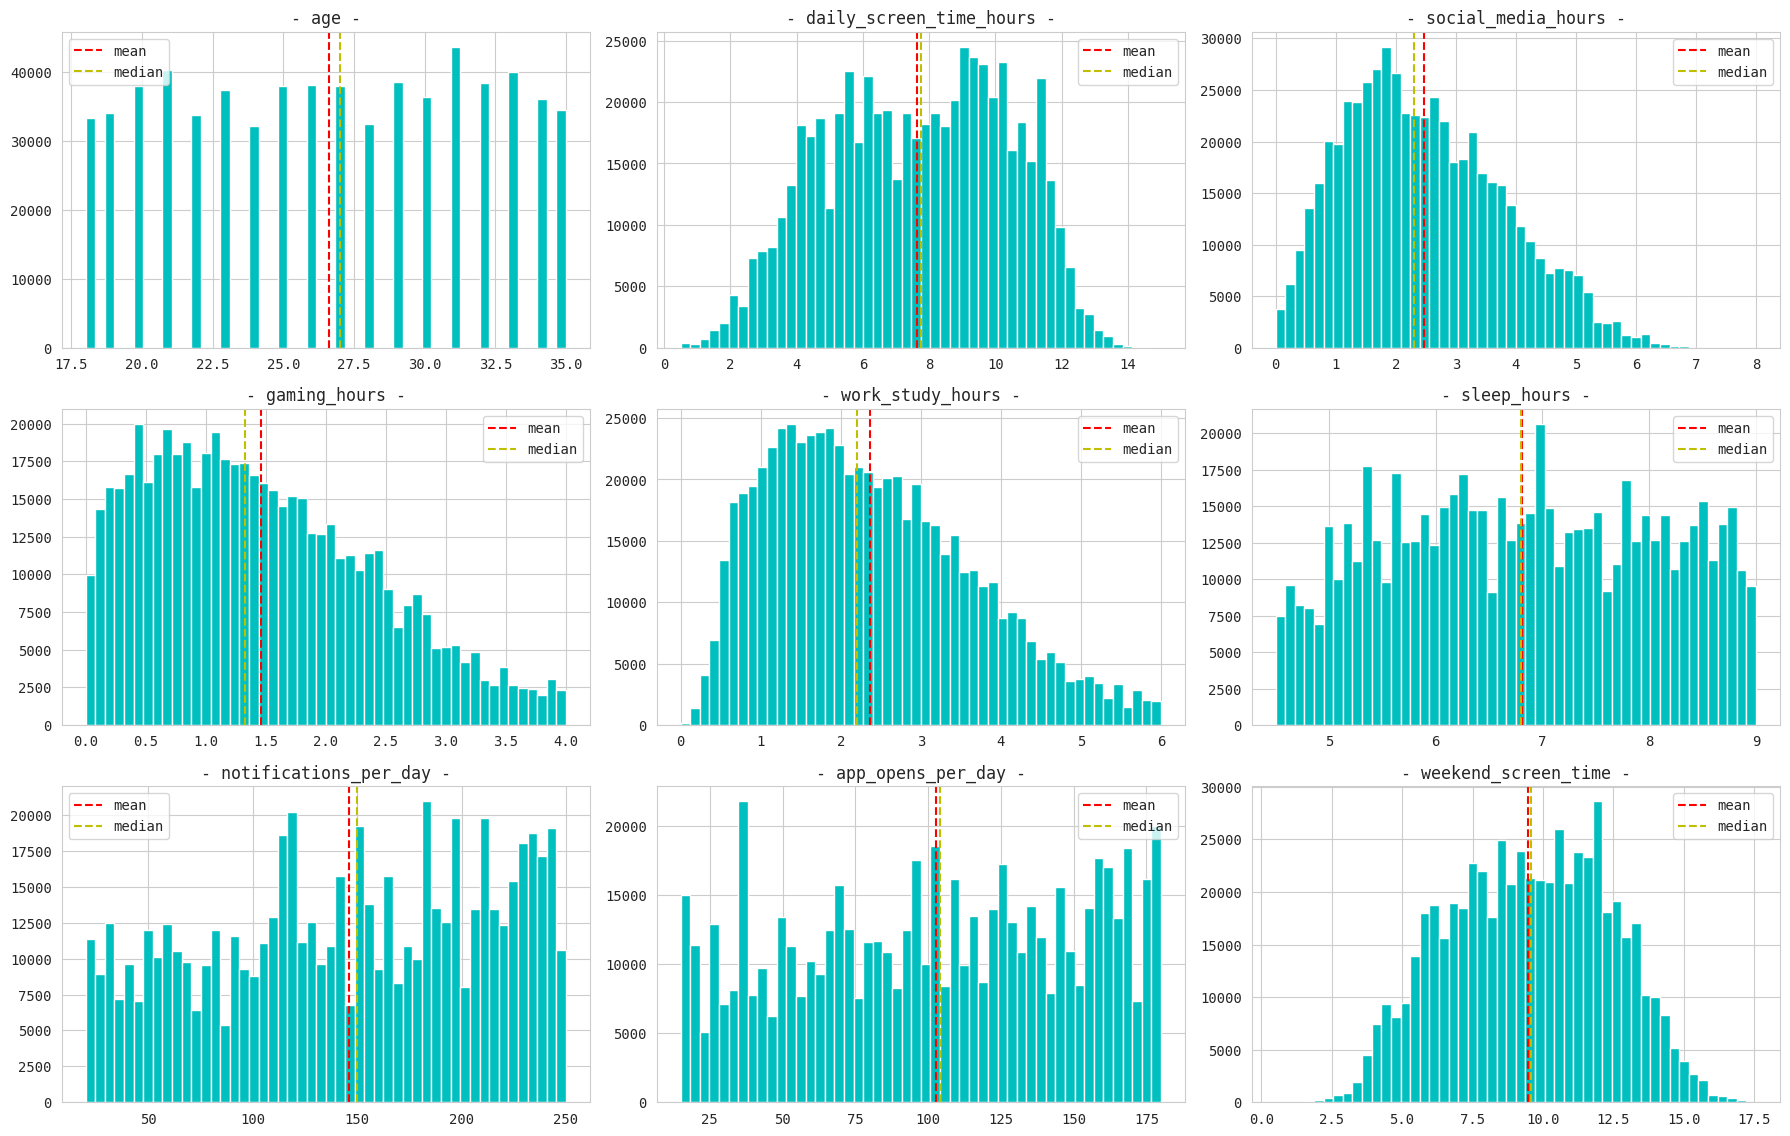

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [12]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [13]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# aggs_ = ["mean", "count"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=aggs_,
#     # fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=aggs_,
#     # fill_nan=True,
# )

# train[orig_cols][:10].T

In [14]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
# # -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS, title="nums_to_cats"):
#     n = f"{c}_cat"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
# FEATURES.extend(CATS_2)
## ------------------------------------------------------------
## -- Factorize all features --
for c in tqdm(FEATURES, desc="factorize_cats"): # +INTER + new_cats
    combined[c] = combined[c].factorize()[0]

# for c in tqdm(CATS, desc="categorize_cats"):
#     combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 12


factorize_cats: 100%|██████████| 12/12 [00:00<00:00, 42.21it/s]


Label encoding complete!


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,-1,0,0,0,0,0,0,0,0,0,0,1.0
1,1,0,1,-1,1,1,1,1,-1,1,0,0,0.0
2,2,1,-1,-1,-1,2,2,2,1,1,1,1,0.0
3,3,2,2,1,2,3,3,3,2,2,1,-1,1.0
4,4,3,3,2,3,4,-1,-1,3,1,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,12,783,374,145,109,88,168,3,786,0,-1,0,1.0
691365,7,342,163,82,248,312,102,77,154,1,2,0,1.0
691366,-1,-1,-1,-1,43,292,-1,164,599,2,0,0,1.0
691367,12,26,137,196,150,40,91,135,290,2,-1,-1,1.0


# ML TRAINING

In [15]:
y_ = np.ascontiguousarray(train[TARGET], dtype=np.float64)
_y = np.where(train[TARGET] == 1, 1, -1)

print(np.unique(y_), np.unique(_y))
print(y_[:5], _y[:5])

[0. 1.] [-1  1]
[1. 0. 0. 1. 1.] [ 1 -1 -1  1  1]


In [16]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, use_original=False):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    fold_scores = []
    feature_importances  = []

    # Handle optional original table aggregations securely if flags enable them
    if use_original and "original_TE" in globals():
        feats = features.copy()
        # "mean" for bagging | ("mean", "count", "std", "skew") for goss
        aggs_ = ["mean", "count"] 

        X_tr, orig_cols = original_TE(
            orig, train_data, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test, target=TARGET, features=BASE, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
        X_ts = test_df[features]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        print(f"shape: {X_train.shape}")
        if idx == 1:
            display(X_train.head())

        # ---------------------------------------------------------------
        if "gibbs" in model_name:
            # y_train = np.ascontiguousarray(y_train, dtype=np.float64)
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
                    ("myfm", MyFMGibbsClassifier(rank=params["rank"], random_seed=0)),
                ], 
                verbose=True,
            )
            model.fit(X_train, y_train.values, myfm__n_iter=params["n_iter"], myfm__n_kept_samples=50)  
        elif "als" in model_name:
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
                    ("fast_als", als_Classification(**params, random_state=0)),
                ],
                verbose=True,
            )
            y_train = np.where(y_train == 1, 1.0, -1.0)
            model.fit(X_train, y_train)
        else:
            model = Pipeline(
                [
                    ("ohe", OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
                    ("fast_sgd", sgd_Classification(**params["fastfm"])),
                ],
                verbose=True,
            )
            y_train = np.where(y_train == 1, 1.0, -1.0)
            model.fit(X_train, y_train)

        oof_preds[val_idx] = model.predict_proba(X_valid)
        test_preds += model.predict_proba(X_test) / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del X_test, model
        gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits
    
    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        # 'model': model,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [17]:
all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,-1,0,0,0,0,0,0,0,0,0,0,1.0
1,1,0,1,-1,1,1,1,1,-1,1,0,0,0.0
2,2,1,-1,-1,-1,2,2,2,1,1,1,1,0.0
3,3,2,2,1,2,3,3,3,2,2,1,-1,1.0
4,4,3,3,2,3,4,-1,-1,3,1,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,12,783,374,145,109,88,168,3,786,0,-1,0,1.0
691365,7,342,163,82,248,312,102,77,154,1,2,0,1.0
691366,-1,-1,-1,-1,43,292,-1,164,599,2,0,0,1.0
691367,12,26,137,196,150,40,91,135,290,2,-1,-1,1.0


In [18]:
# try:
#     import optuna
# except:
#     !pip install -q optuna
#     import optuna

# def objective(trial):
#     params = {
#         "n_iter": 100,
#         "rank": 4,
#         "init_stdev": trial.suggest_float("init_stdev", 0.01, 3.0),
#         "l2_reg_w": trial.suggest_float("l2_reg_w", 0.01, 3.0),
#         "l2_reg_V": trial.suggest_float("l2_reg_V", 0.01, 3.0),
#         "l2_reg": trial.suggest_float("l2_reg", 0.01, 3.0),
#         "random_state": 42,
#     }

#     # "ffm_fastFM_als", "ffm_fastFM_sgd"
#     n = "ffm_fastFM_als"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         # use_original=True,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="Optuna_Search")

# # Run optimization for 50 trials
# study.optimize(objective, n_trials=20, timeout=3600, show_progress_bar=True, gc_after_trial=True)

In [19]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.04 --
# # --- Optimization Complete ---
# # Best Trial ROC-AUC Score: 0.965555
# # Best Hyperparameters:
# # {'depth': 6, 'temperature': 0.3, 'l2_reg': 0.10348352129966662}

# # --- Optimization Complete ---
# # Best Trial ROC-AUC Score: 0.965525
# # Best Hyperparameters:
# # {'depth': 5, 'temperature': 0.4, 'strength': 0.6, 'l2_reg': 1.2224361482015358}

In [20]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

# ## -- Optimization history across trials
# optuna.visualization.plot_slice(study).show()

# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

In [21]:
## --- Trainer ---
# v1_myFM_gibbs_rank2
params = {
    "n_iter": 200,
    "rank": 4,
    "init_stdev": 0.1, # 0.1
    "l2_reg_w": 1.0, # 0.1
    "l2_reg_V": 1.0, # 0.5
    "l2_reg": 1.0, # 1.0
}

# f"fm_myfm_gibbs{params["rank"]}", f"fm_fastfm_als{params["rank"]}", f"fm_fastfm_sgd{params["rank"]}"
for n in [f"fm_myfm_gibbs{params["rank"]}"]:
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        use_original=True,
    )


===== Starting CV: fm_myfm_gibbs4 | CPU: 4 =====


Original augment complete!: 100%|██████████| 12/12 [00:00<00:00, 20.88it/s]



+++++ FOLD 1/5 | shape: (553095, 36)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,0,-1,0,0,0,0,0,0,0,0,0,0,0.752660,376.0,NaN,NaN,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0
1,1,0,1,-1,1,1,1,1,-1,1,0,0,0.712500,400.0,0.333333,9.0,0.555556,18.0,NaN,NaN,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,NaN,NaN,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0
2,2,1,-1,-1,-1,2,2,2,1,1,1,1,0.671679,399.0,0.294118,17.0,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0
3,3,2,2,1,2,3,3,3,2,2,1,-1,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,NaN,NaN
4,4,3,3,2,3,4,-1,-1,3,1,0,0,0.748252,429.0,1.000000,6.0,0.545455,11.0,0.807692,26.0,0.666667,15.0,0.500000,18.0,NaN,NaN,NaN,NaN,1.000000,4.0,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0


[Pipeline] ............... (step 1 of 2) Processing ohe, total=   2.3s


...

[Pipeline] .............. (step 2 of 2) Processing myfm, total= 2.8min
 • FOLD 3 AUC: 0.962936

+++++ FOLD 4/5 | shape: (553095, 36)
[Pipeline] ............... (step 1 of 2) Processing ohe, total=   2.3s


w0 = 1.65 : 100%|██████████| 200/200 [02:48<00:00,  1.19it/s]


[Pipeline] .............. (step 2 of 2) Processing myfm, total= 2.8min
 • FOLD 4 AUC: 0.963294

+++++ FOLD 5/5 | shape: (553096, 36)
[Pipeline] ............... (step 1 of 2) Processing ohe, total=   2.3s


w0 = 1.65 : 100%|██████████| 200/200 [02:48<00:00,  1.18it/s]


[Pipeline] .............. (step 2 of 2) Processing myfm, total= 2.8min
 • FOLD 5 AUC: 0.962188

5-FOLD CV: fm_myfm_gibbs4 | (553096, 36)
 • Fold 1 AUC: 0.962067
 • Fold 2 AUC: 0.962635
 • Fold 3 AUC: 0.962936
 • Fold 4 AUC: 0.963294
 • Fold 5 AUC: 0.962188
-------------------------------------------------|
Overall AUC: 0.962623
Average AUC: 0.962624 ± 0.000458
-------------------------------------------------|
15.13 mins



In [22]:
# rank=2 | n_iter=300

# ==================================================
# 5-FOLD CV: fm_myfm_gibbs___ | (165619, 36)
# ==================================================
#  • Fold 1 AUC: 0.956790
#  • Fold 2 AUC: 0.957789
#  • Fold 3 AUC: 0.956425
#  • Fold 4 AUC: 0.958086
#  • Fold 5 AUC: 0.957394
# -------------------------------------------------|
# Overall AUC: 0.957291
# Average AUC: 0.957297 ± 0.000615
# -------------------------------------------------|
# 7.33 mins

# ==================================================
# 5-FOLD CV: fm_fastfm_als | (165619, 36)
# ==================================================
#  • Fold 1 AUC: 0.951418
#  • Fold 2 AUC: 0.950947
#  • Fold 3 AUC: 0.949478
#  • Fold 4 AUC: 0.952281
#  • Fold 5 AUC: 0.951269
# -------------------------------------------------|
# Overall AUC: 0.951076
# Average AUC: 0.951078 ± 0.000914
# -------------------------------------------------|
# 18.06 mins

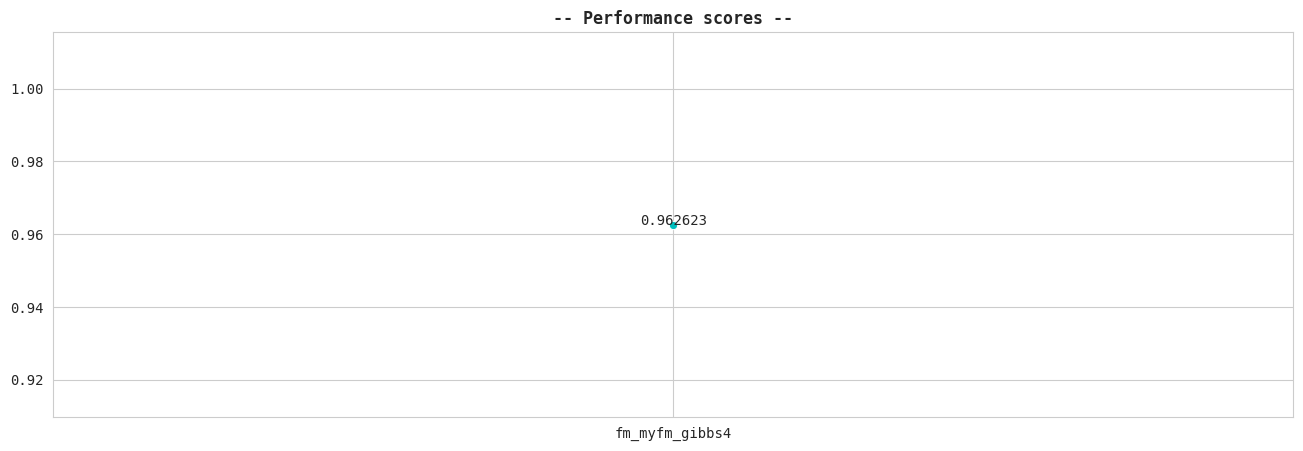

In [23]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("-- Performance scores --", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

# plt.tight_layout()
plt.show()

fm_myfm_gibbs4_962623 saved!


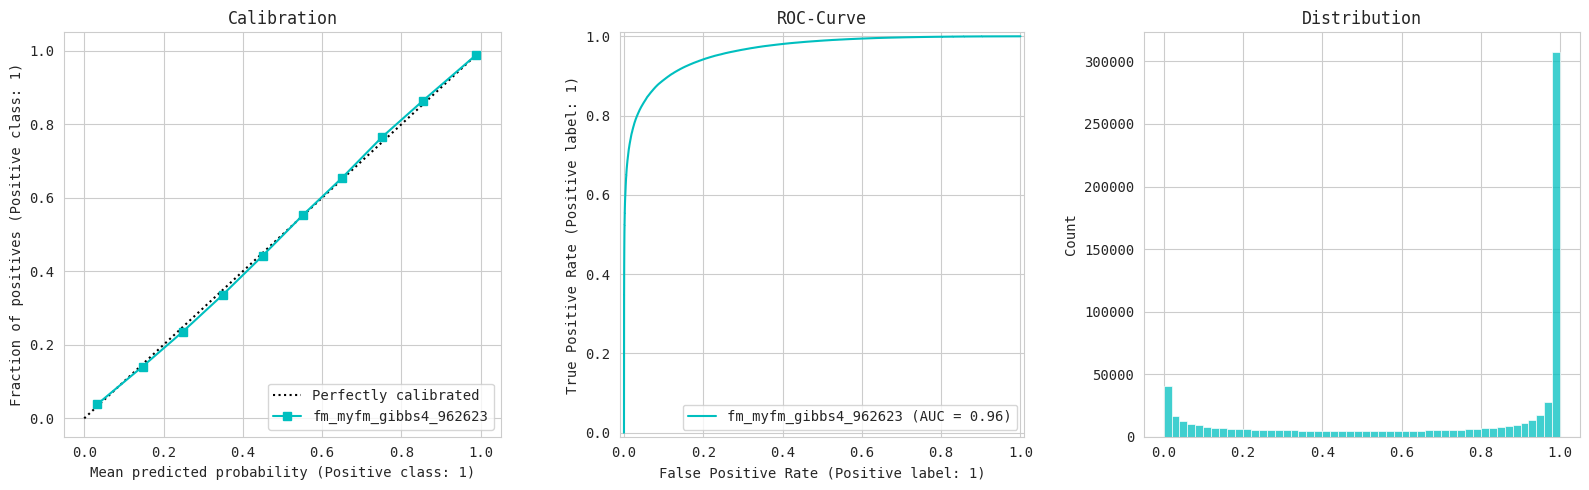

In [24]:
## -- Get oof predictions --

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [25]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

fm_myfm_gibbs4_962623 saved! (296302,)



,fm_myfm_gibbs4_
0,0.999985
1,0.982311
2,0.810295
3,0.997879
4,0.999791
...,...
296297,0.999987
296298,0.509231
296299,0.361979
296300,0.855553


In [26]:
model_results.describe()

,fm_myfm_gibbs4_
count,2.963020e+05
mean,7.087422e-01
std,3.690169e-01
min,1.165124e-08
25%,3.827080e-01
50%,9.504975e-01
75%,9.995997e-01
max,1.000000e+00


In [27]:
if len(model_results.columns) > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')
    
    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title('CDF Comparison of 5 Probability Distributions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [28]:
# !rm -r /kaggle/working